# Лабораторная работа №6 
## Слесарев Никита ФИТ-231
№1 (2 балла)
Изучите материал https://cloud.mail.ru/public/S4Pu/zPnKHX7qT. Выполните задания из
файла https://cloud.mail.ru/public/KtLN/hjdfs92YL. 

Выполено в отдельном файле


№2 (2 балла)
Выполните задания из файла https://cloud.mail.ru/public/CDUu/PZPV4W8FX. Данные
скачайте отсюда https://cloud.mail.ru/public/ZyCV/8w6p1i19o. 

In [2]:
# Практическое задание №1.6.2 — с обработкой пропусков
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error

# 1. Загрузка
df = pd.read_csv('house_price.csv')

# 2. Оставляем числовые признаки
numeric_dtypes = ['int64', 'float64']
numerics = [col for col in df.columns if df[col].dtype in numeric_dtypes]
df = df[numerics]

# 3. Удаляем 'Id', если есть
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# 4. Обработка пропусков (вместо dropna!)
print("Пропуски до обработки:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Удалим столбцы, где более 50% пропусков
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)

# Заполним оставшиеся пропуски медианой
df = df.fillna(df.median())

print(f"\nРазмер после обработки пропусков: {df.shape}")

# Проверка: есть ли строки?
if df.empty or len(df) == 0:
    raise ValueError("После обработки не осталось данных!")

# 5. Разделение на X и y
if 'SalePrice' not in df.columns:
    raise KeyError("Столбец 'SalePrice' отсутствует после очистки!")

X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# 6. Разделение на выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 7. LassoCV
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)

print("\n=== LassoCV ===")
print(f"R² на тесте: {lasso.score(X_test, y_test):.4f}")
print(f"Выбранное alpha: {lasso.alpha_:.4f}")
print(f"Нулевых коэффициентов: {(lasso.coef_ == 0).sum()} из {len(lasso.coef_)}")

# 8. RidgeCV
ridge = RidgeCV(cv=5)
ridge.fit(X_train, y_train)

print("\n=== RidgeCV ===")
print(f"R² на тесте: {ridge.score(X_test, y_test):.4f}")
print(f"Выбранное alpha: {ridge.alpha_:.4f}")

# Сравнение
print("\n=== Вывод ===")
if lasso.score(X_test, y_test) > ridge.score(X_test, y_test):
    print("LassoCV лучше справляется с прогнозированием.")
else:
    print("RidgeCV даёт лучшее качество.")

Пропуски до обработки:
LotFrontage     259
MasVnrArea        8
GarageYrBlt      81
Unnamed: 81    1460
dtype: int64

Размер после обработки пропусков: (1460, 37)

=== LassoCV ===
R² на тесте: 0.7701
Выбранное alpha: 230961.3249
Нулевых коэффициентов: 26 из 36

=== RidgeCV ===
R² на тесте: 0.8226
Выбранное alpha: 10.0000

=== Вывод ===
RidgeCV даёт лучшее качество.


№3 (2 балла)
Обучите модель линейной регрессии на данных согласно вашему варианту. Выведите
угловой коэффициент, точку пересечения с осью ординат и точность.

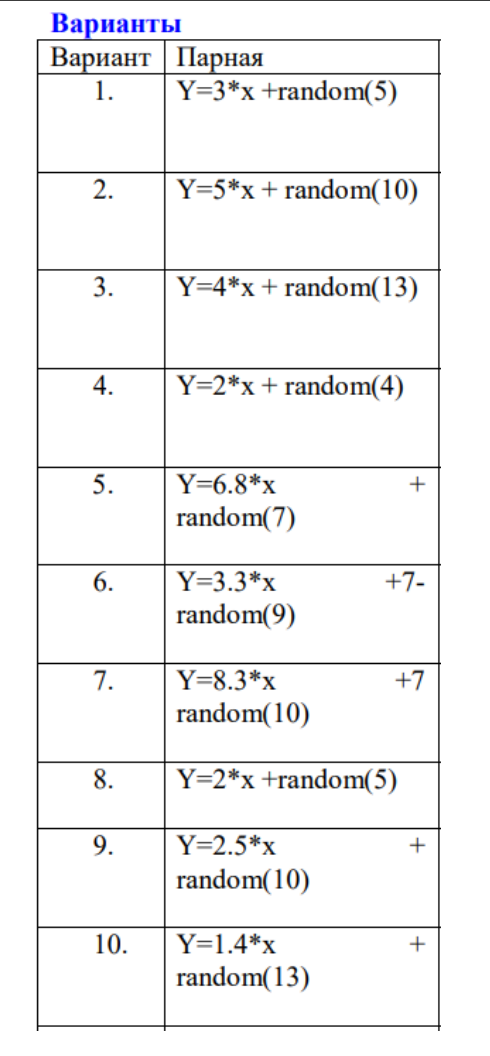

Вариант №6


=== Результаты ===
Угловой коэффициент (slope): 3.3268
Точка пересечения с осью Y (intercept): 2.7191
Точность (коэффициент детерминации R²): 0.9831


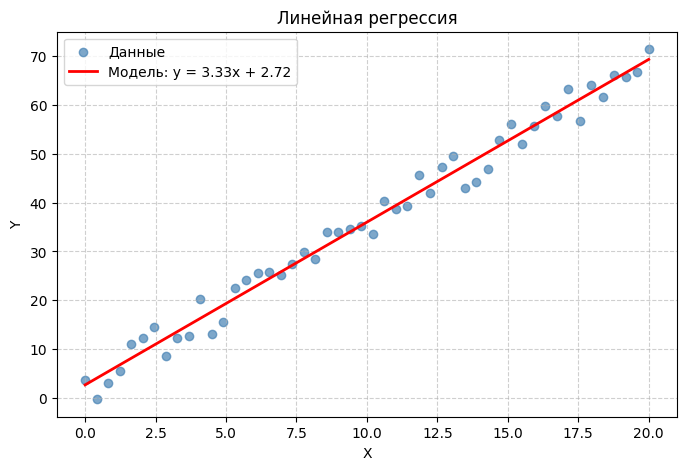

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Генерация данных согласно формуле: Y = 3.3*X + 7 - random(9)
np.random.seed(42)  # для воспроизводимости
x = np.linspace(0, 20, 50).reshape(-1, 1)  # 50 точек от 0 до 20
noise = np.random.uniform(0, 9, size=x.shape[0])  # random(9) → [0, 9)
y = 3.3 * x.flatten() + 7 - noise

# 2. Обучение модели линейной регрессии
model = LinearRegression()
model.fit(x, y)

# 3. Параметры модели
slope = model.coef_[0]      # угловой коэффициент
intercept = model.intercept_  # точка пересечения с осью Y

# 4. Точность (коэффициент детерминации R²)
r2 = model.score(x, y)

# 5. Вывод
print("=== Результаты ===")
print(f"Угловой коэффициент (slope): {slope:.4f}")
print(f"Точка пересечения с осью Y (intercept): {intercept:.4f}")
print(f"Точность (коэффициент детерминации R²): {r2:.4f}")

# 6. Визуализация (опционально)
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='steelblue', label='Данные', alpha=0.7)
plt.plot(x, model.predict(x), color='red', linewidth=2, label=f'Модель: y = {slope:.2f}x + {intercept:.2f}')
plt.title('Линейная регрессия')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

№4 (3 балла)
Скачайте датасет https://cloud.mail.ru/public/SAi2/M1AzFm7BC, в котором по дням
записаны календарная информация и погодные условия, характеризующие
автоматизированные пункты проката велосипедов, а также число прокатов в этот день (это
значение необходимо предсказывать).
Для каждого дня проката известны следующие признаки (как они были указаны в источнике
данных):
 season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
 yr: 0 - 2011, 1 - 2012
 mnth: от 1 до 12
 holiday: 0 - нет праздника, 1 - есть праздник
 weekday: от 0 до 6
 workingday: 0 - нерабочий день, 1 - рабочий день
 weathersit: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень,
туман)
 temp: температура в Цельсиях
 atemp: температура по ощущениям в Цельсиях
 hum: влажность
 windspeed(mph): скорость ветра в милях в час
 windspeed(ms): скорость ветра в метрах в секунду
 cnt: количество арендованных велосипедов (это целевой признак, его мы будем
предсказывать)
Выполните следующие шаги:
1. Покажите на графиках, как целевой признак зависит от остальных. Каков характер
зависимости числа прокатов от месяца? Укажите один или два признака, от которых
число прокатов скорее всего зависит линейно.
2. Есть ли в данных похожие или дублирующие друг друга признаки? Как вы можете
показать их похожесть? Удалите такие признаки из датасета.
3. Разбейте данные на тренировочные и тестовые. Обучите модель линейной
регрессии. Выведите точность предсказания модели для тестовых данных. 

=== 1. Визуализация зависимости cnt от признаков ===


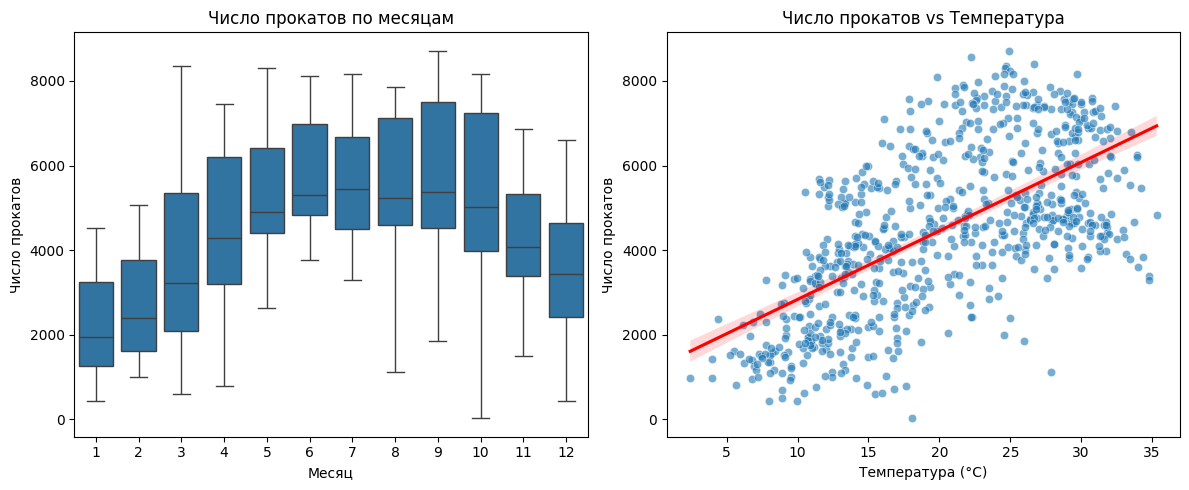

- Число прокатов максимум летом (месяцы 6–8), минимум зимой.
- Наиболее линейная зависимость: от `temp` и `atemp`.

=== 2. Поиск похожих признаков ===


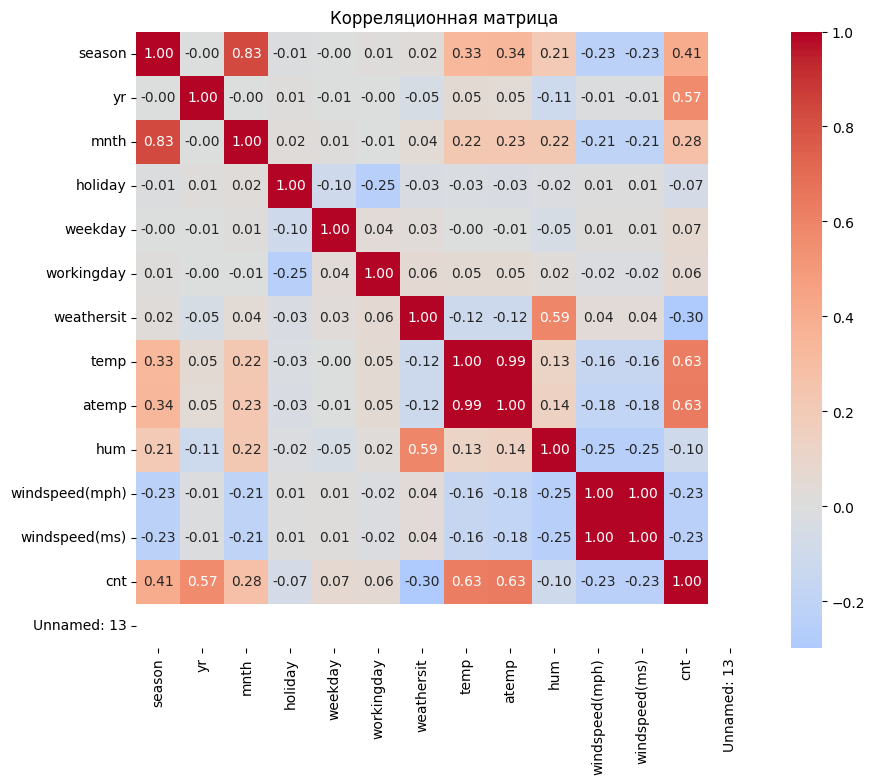


Выявлены дублирующие признаки:
- 'temp' и 'atemp' (очень высокая корреляция)
- 'windspeed(mph)' и 'windspeed(ms)' (линейная связь: 1 mph ≈ 0.447 м/с)

После удаления: 12 признаков осталось.

=== 3. Линейная регрессия ===
Точность модели (R²) на тестовых данных: 0.8322

Топ-5 признаков по влиянию на число прокатов:
      Признак  Коэффициент
1          yr  2029.732127
6  weathersit  -643.610427
0      season   541.910403
3     holiday  -438.434350
5  workingday   156.213945


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Загрузка данных
df = pd.read_csv('bikes_rent.csv', decimal=',')

# === 1. Графики зависимости целевого признака (cnt) от других ===
print("=== 1. Визуализация зависимости cnt от признаков ===")

# Зависимость от месяца (mnth)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='mnth', y='cnt')
plt.title('Число прокатов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Число прокатов')

# Зависимость от температуры (temp) — ожидаем линейную связь
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='temp', y='cnt', alpha=0.6)
sns.regplot(data=df, x='temp', y='cnt', scatter=False, color='red')
plt.title('Число прокатов vs Температура')
plt.xlabel('Температура (°C)')
plt.ylabel('Число прокатов')

plt.tight_layout()
plt.show()

# Вывод: 
print("- Число прокатов максимум летом (месяцы 6–8), минимум зимой.")
print("- Наиболее линейная зависимость: от `temp` и `atemp`.")

# === 2. Поиск и удаление дублирующих признаков ===
print("\n=== 2. Поиск похожих признаков ===")

# Посмотрим на корреляцию
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Корреляционная матрица')
plt.show()

# Видим, что `temp` и `atemp` сильно коррелируют (r > 0.99)
# Также `windspeed(mph)` и `windspeed(ms)` — это одно и то же в разных единицах
print("\nВыявлены дублирующие признаки:")
print("- 'temp' и 'atemp' (очень высокая корреляция)")
print("- 'windspeed(mph)' и 'windspeed(ms)' (линейная связь: 1 mph ≈ 0.447 м/с)")

# Удалим избыточные признаки
df_clean = df.drop(columns=['atemp', 'windspeed(mph)'])

print(f"\nПосле удаления: {df_clean.shape[1]} признаков осталось.")

from sklearn.impute import SimpleImputer

# === 3. Линейная регрессия ===
print("\n=== 3. Линейная регрессия ===")

X = df_clean.drop('cnt', axis=1)
y = df_clean['cnt']

# Удалим столбцы, где все значения — NaN (например, 'Unnamed: 13')
X = X.dropna(axis=1, how='all')

# Заполним пропуски
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns  # Теперь X.columns совпадает с числом столбцов в X_imputed
)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.25, random_state=42
)

# Обучение
model = LinearRegression()
model.fit(X_train, y_train)

r2 = model.score(X_test, y_test)
print(f"Точность модели (R²) на тестовых данных: {r2:.4f}")

# Коэффициенты
coef_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': model.coef_
}).sort_values('Коэффициент', key=abs, ascending=False)

print("\nТоп-5 признаков по влиянию на число прокатов:")
print(coef_df.head())

№5 (3 балла)
С сайта https://www.kaggle.com/ скачайте датасет на ваш выбор для обучения модели
линейной регрессии. Выполните следующие действия:
1. Опишите выбранный набор данных: контекст данных, какие данные есть в наборе,
как можно будет использовать полученные результаты предсказания.
2. Выберите выходную прогнозируемую переменную.
3. Постройте линейную регрессионную модель с несколькими значимыми
параметрами (оцените корреляции между признаками, последовательно добавляйте
признаки и сравнивайте качество получаемых моделей, оцените адекватность
модели).
4. Интерпретируйте результаты моделирования (что значит полученная формула,
какие переменные вносят больший вклад).
5. Спрогнозируйте несколько новых значений с помощью построенной модели.


In [17]:
# Датасет содержит статистику постов в Instagram: сколько раз пост был показан (Impressions), откуда пришёл трафик (Home, Hashtags, Explore и др.), и сколько получено лайков, сохранений, комментариев, подписок.
# Числовые: Impressions, From Home, From Hashtags, From Explore, From Other, Saves, Comments, Shares, Likes, Profile Visits, Follows Текстовые: Caption текст поста, Hashtags хештеги
# Можно предсказывать число подписок (Follows)
# Модель поможет авторам оптимизировать контент: например, понять, сколько сохранений или лайков нужно получить, чтобы получить X подписок.

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Загрузка с обработкой кодировки
df = pd.read_csv(
    'Instagram_data.csv',
    encoding='utf-8',
    encoding_errors='replace',  # заменяет проблемные символы
    decimal=','                 # если числа с запятой (маловероятно, но на всякий)
)

# Убедимся, что числовые столбцы — числа
numeric_cols = ['Impressions', 'From Home', 'From Hashtags', 'From Explore', 'From Other',
                'Saves', 'Comments', 'Shares', 'Likes', 'Profile Visits', 'Follows']

for col in numeric_cols:
    if col in df.columns:
        # Удаляем недопустимые символы и преобразуем в число
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Удаляем строки с NaN в целевой переменной
df = df.dropna(subset=['Follows'])

# Дальнейший анализ (как в предыдущем ответе)
X = df[['Likes', 'Saves', 'Comments', 'Shares', 'Profile Visits']]
y = df['Follows']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"R²: {model.score(X_test, y_test):.4f}")

# Коэффициенты
coef_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': model.coef_
})
print("\n=== Коэффициенты модели ===")
print(coef_df)

print(f"\nСвободный член (intercept): {model.intercept_:.2f}")

# Пример новых данных
new_data = pd.DataFrame({
    'Likes': [200, 150],
    'Saves': [100, 80],
    'Comments': [10, 8],
    'Shares': [5, 4],
    'Profile Visits': [50, 40]
})

pred_follows = model.predict(new_data)
print("\n=== Прогноз подписок ===")
for i, pred in enumerate(pred_follows):
    print(f"Пост {i+1}: предсказано {pred:.1f} подписок")


R²: 0.7549

=== Коэффициенты модели ===
          Признак  Коэффициент
0           Likes     0.022412
1           Saves     0.070704
2        Comments    -1.290258
3          Shares    -0.271468
4  Profile Visits     0.354079

Свободный член (intercept): -1.08

=== Прогноз подписок ===
Пост 1: предсказано 13.9 подписок
Пост 2: предсказано 10.7 подписок


№6 (3 балла)
Различные метрики качества реализованы в пакете sklearn.metrics. Подробнее о них
смотрите в лекции или в учебных пособиях, например, https://github.com/esokolov/mlcourse-msu/blob/master/ML15/lecture-notes/Sem05_metrics.pdf.
1. Загрузите файл classification.csv (https://cloud.mail.ru/public/QGde/JFrAntvih). В нем
записаны истинные классы объектов выборки (колонка true) и ответы некоторого
классификатора (колонка predicted).
2. Заполните таблицу ошибок классификации:

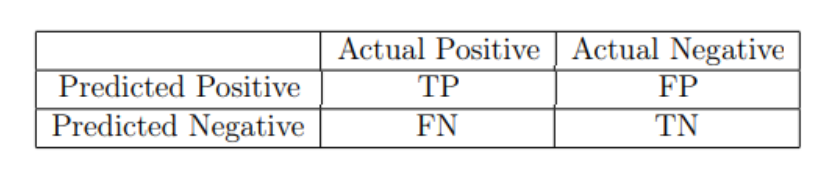

Для этого подсчитайте величины TP, FP, FN и TN согласно их определениям.
Например, FP — это количество объектов, имеющих класс 0, но отнесенных
алгоритмом к классу 1.
3. Посчитайте основные метрики качества классификатора:
a. Accuracy (доля верно угаданных) — sklearn.metrics.accuracy
b. Precision (точность) — sklearn.metrics.accuracy.precision_score
c. Recall (полнота) — sklearn.metrics.recall_score
d. F-мера — sklearn.metrics.f1_score

In [20]:
import pandas as pd

# Загрузка данных
df = pd.read_csv('classification.csv')

# Извлечение истинных и предсказанных меток
true = df['true']
pred = df['pred']

# Расчёт TP, FP, FN, TN
TP = ((true == 1) & (pred == 1)).sum()   # True Positive
FP = ((true == 0) & (pred == 1)).sum()   # False Positive
FN = ((true == 1) & (pred == 0)).sum()   # False Negative
TN = ((true == 0) & (pred == 0)).sum()   # True Negative

# Вывод таблицы ошибок
print("Таблица ошибок классификации:")
print(f"{'':<20} | {'Actual Positive':<16} | {'Actual Negative'}")
print("-" * 52)
print(f"{'Predicted Positive':<20} | {TP:<16} | {FP}")
print(f"{'Predicted Negative':<20} | {FN:<16} | {TN}")

# Дополнительно: вывод в виде DataFrame
conf_matrix = pd.DataFrame(
    [[TP, FP],
     [FN, TN]],
    columns=['Actual Positive', 'Actual Negative'],
    index=['Predicted Positive', 'Predicted Negative']
)
print("\nDataFrame с таблицей ошибок:")
print(conf_matrix)

Таблица ошибок классификации:
                     | Actual Positive  | Actual Negative
----------------------------------------------------
Predicted Positive   | 43               | 34
Predicted Negative   | 59               | 64

DataFrame с таблицей ошибок:
                    Actual Positive  Actual Negative
Predicted Positive               43               34
Predicted Negative               59               64


№7 (3 балла)
С сайта https://www.kaggle.com/ скачайте датасет на ваш выбор для обучения модели
логистической регрессии (задача классификации). Выполните следующие действия:
1. Опишите выбранный набор данных: контекст данных, какие данные есть в наборе,
как можно будет использовать полученные результаты классификации.
2. Постройте классификацию, используя логистическую регрессионную модель.
Оцените качество работы модели.
3. Спрогнозируйте несколько новых значений с помощью построенной модели.

In [22]:
# Датасет содержит метрики эффективности Instagram-постов: охваты, лайки, сохранения, комментарии, визиты в профиль и число новых подписок 
# Будем классифицировать пост как «успешный», если Follows > 10, иначе — «неуспешный».

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer

# Загрузка данных (с обработкой кодировки)
df = pd.read_csv('Instagram_data.csv', encoding='utf-8', encoding_errors='replace')

# Выбор признаков
features = ['Likes', 'Saves', 'Comments', 'Shares', 'Profile Visits']
X = df[features]
y = (df['Follows'] > 10).astype(int)  # 1 — если Follows > 10, иначе 0

# Обработка пропусков
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=features)

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Обучение модели
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Оценка качества
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("=== Качество модели ===")
print(f"Точность (Accuracy): {accuracy:.4f}")
print("\nОтчёт классификации:")
print(classification_report(y_test, y_pred, target_names=['Неуспешный', 'Успешный']))


# Пример новых постов
new_posts = pd.DataFrame({
    'Likes': [100, 250],
    'Saves': [50, 120],
    'Comments': [5, 15],
    'Shares': [3, 8],
    'Profile Visits': [30, 70]
})

# Заполнение пропусков (если есть)
new_posts_imputed = pd.DataFrame(imputer.transform(new_posts), columns=features)

# Прогноз
predictions = model.predict(new_posts_imputed)
probabilities = model.predict_proba(new_posts_imputed)

print("\n=== Прогноз для новых постов ===")
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    status = "Успешный" if pred == 1 else "Неуспешный"
    prob_success = prob[1] * 100
    print(f"Пост {i+1}: {status} (вероятность успеха: {prob_success:.1f}%)")

=== Качество модели ===
Точность (Accuracy): 0.8000

Отчёт классификации:
              precision    recall  f1-score   support

  Неуспешный       0.84      0.84      0.84        19
    Успешный       0.73      0.73      0.73        11

    accuracy                           0.80        30
   macro avg       0.78      0.78      0.78        30
weighted avg       0.80      0.80      0.80        30


=== Прогноз для новых постов ===
Пост 1: Неуспешный (вероятность успеха: 13.3%)
Пост 2: Успешный (вероятность успеха: 82.6%)
